# 🤖 Notebook 02 — Machine Learning y LLMs

**Proyecto 1 · Curso Machine Learning Engineering (DSRP 2026)**

**Contenido:**
1. Regresión Logística (modelo baseline)
2. Árbol de Decisión
3. Random Forest (Reto ML 1)
4. Comparación de modelos y métricas de evaluación
5. Integración con LLMs (OpenAI GPT-4o-mini)
   - 5.1 Interpretación de importancia de features
   - 5.2 Clasificación few-shot con LLM
   - 5.3 Comparación LLM vs modelos clásicos

In [1]:
import os
import sys
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from openai import OpenAI
from dotenv import load_dotenv

sys.path.insert(0, os.path.abspath('..'))
from src.preprocessing import FEATURE_COLS
from src.training import get_model, train_model, save_model
from src.evaluation import (
    evaluate_model, plot_confusion_matrix, plot_roc_curve, compare_models
)

load_dotenv(os.path.join(os.path.abspath('..'), '.env'))

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100

PROJECT_ROOT  = os.path.abspath('..')
DATA_DIR      = os.path.join(PROJECT_ROOT, 'data')
ARTIFACTS_DIR = os.path.join(PROJECT_ROOT, 'artifacts')
RANDOM_STATE  = 42

print('Librerías cargadas correctamente ✓')


Librerías cargadas correctamente ✓


In [2]:
# Carga de datos preprocesados (generados por Notebook 01)
train_df = pd.read_parquet(os.path.join(DATA_DIR, 'preprocessed_train.parquet'))
test_df  = pd.read_parquet(os.path.join(DATA_DIR, 'preprocessed_test.parquet'))

X_train = train_df[FEATURE_COLS].values
y_train = train_df['quality_binary'].values
X_test  = test_df[FEATURE_COLS].values
y_test  = test_df['quality_binary'].values

print(f'Train: {X_train.shape} — Positivos: {y_train.mean():.1%}')
print(f'Test:  {X_test.shape}  — Positivos: {y_test.mean():.1%}')


Train: (1087, 11) — Positivos: 52.9%
Test:  (272, 11)  — Positivos: 52.9%


## 1. Regresión Logística (Baseline)

Modelo lineal que estima la probabilidad de pertenecer a cada clase. Sirve como baseline para comparar con modelos más complejos.

In [3]:
lr = get_model('logistic_regression', max_iter=1000, random_state=RANDOM_STATE)
lr = train_model(lr, X_train, y_train)

lr_metrics = evaluate_model(lr, X_test, y_test, 'Regresión Logística')
print('=== Métricas — Regresión Logística ===')
for k, v in lr_metrics.items():
    print(f'  {k:<12}: {v:.4f}')

print()
print(classification_report(y_test, lr.predict(X_test),
                             target_names=['Mala calidad', 'Buena calidad']))


=== Métricas — Regresión Logística ===
  accuracy    : 0.7353
  precision   : 0.7609
  recall      : 0.7292
  f1          : 0.7447
  roc_auc     : 0.8116

               precision    recall  f1-score   support

 Mala calidad       0.71      0.74      0.73       128
Buena calidad       0.76      0.73      0.74       144

     accuracy                           0.74       272
    macro avg       0.73      0.74      0.73       272
 weighted avg       0.74      0.74      0.74       272



ROC-AUC CV (5-fold): 0.8184 ± 0.0337


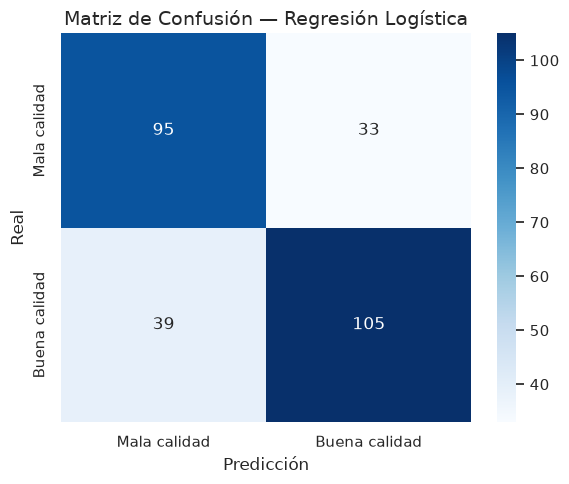

In [4]:
# Validación cruzada (5-fold) — métrica más robusta
lr_cv = cross_val_score(lr, X_train, y_train, cv=5, scoring='roc_auc')
print(f'ROC-AUC CV (5-fold): {lr_cv.mean():.4f} ± {lr_cv.std():.4f}')

fig_cm_lr = plot_confusion_matrix(
    lr, X_test, y_test, 'Regresión Logística',
    save_path=os.path.join(ARTIFACTS_DIR, 'cm_logistic_regression.png')
)
plt.show()


## 2. Árbol de Decisión

Modelo basado en reglas de partición del espacio de features. Interpretable pero propenso al sobreajuste.

In [5]:
dt = get_model('decision_tree', max_depth=6, min_samples_leaf=10, random_state=RANDOM_STATE)
dt = train_model(dt, X_train, y_train)

dt_metrics = evaluate_model(dt, X_test, y_test, 'Árbol de Decisión')
print('=== Métricas — Árbol de Decisión ===')
for k, v in dt_metrics.items():
    print(f'  {k:<12}: {v:.4f}')

print()
print(classification_report(y_test, dt.predict(X_test),
                             target_names=['Mala calidad', 'Buena calidad']))


=== Métricas — Árbol de Decisión ===
  accuracy    : 0.6544
  precision   : 0.6761
  recall      : 0.6667
  f1          : 0.6713
  roc_auc     : 0.7484

               precision    recall  f1-score   support

 Mala calidad       0.63      0.64      0.64       128
Buena calidad       0.68      0.67      0.67       144

     accuracy                           0.65       272
    macro avg       0.65      0.65      0.65       272
 weighted avg       0.65      0.65      0.65       272



ROC-AUC CV (5-fold): 0.7678 ± 0.0399


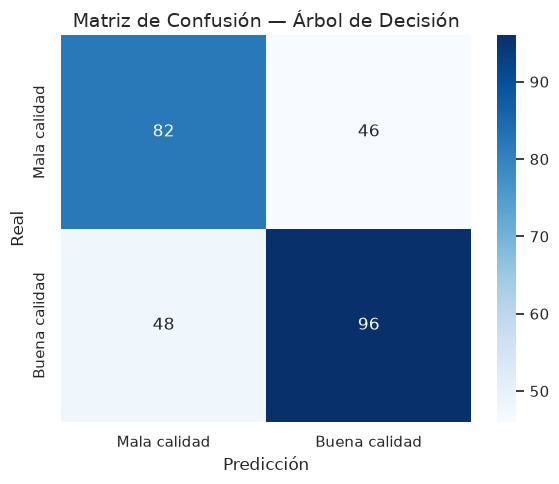

In [6]:
dt_cv = cross_val_score(dt, X_train, y_train, cv=5, scoring='roc_auc')
print(f'ROC-AUC CV (5-fold): {dt_cv.mean():.4f} ± {dt_cv.std():.4f}')

fig_cm_dt = plot_confusion_matrix(
    dt, X_test, y_test, 'Árbol de Decisión',
    save_path=os.path.join(ARTIFACTS_DIR, 'cm_decision_tree.png')
)
plt.show()


## 3. Random Forest (Reto ML 1)

Ensemble de árboles de decisión entrenados con bootstrap y selección aleatoria de features. Robustez al ruido y menor sobreajuste.

In [7]:
rf = get_model('random_forest', n_estimators=200, max_depth=None,
               min_samples_leaf=5, random_state=RANDOM_STATE)
rf = train_model(rf, X_train, y_train)

rf_metrics = evaluate_model(rf, X_test, y_test, 'Random Forest')
print('=== Métricas — Random Forest ===')
for k, v in rf_metrics.items():
    print(f'  {k:<12}: {v:.4f}')

print()
print(classification_report(y_test, rf.predict(X_test),
                             target_names=['Mala calidad', 'Buena calidad']))


=== Métricas — Random Forest ===
  accuracy    : 0.7721
  precision   : 0.7971
  recall      : 0.7639
  f1          : 0.7801
  roc_auc     : 0.8363

               precision    recall  f1-score   support

 Mala calidad       0.75      0.78      0.76       128
Buena calidad       0.80      0.76      0.78       144

     accuracy                           0.77       272
    macro avg       0.77      0.77      0.77       272
 weighted avg       0.77      0.77      0.77       272



ROC-AUC CV (5-fold): 0.8251 ± 0.0455


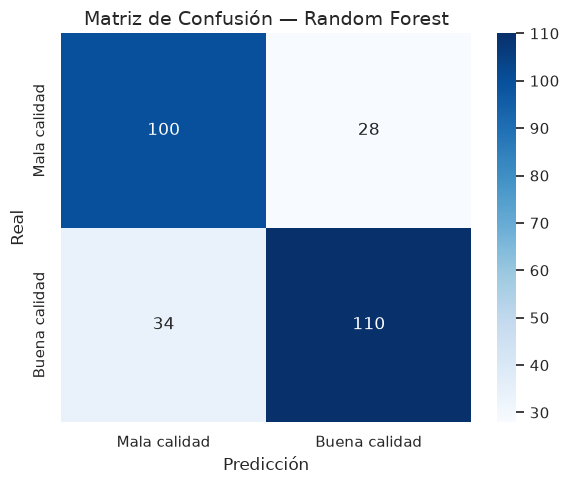

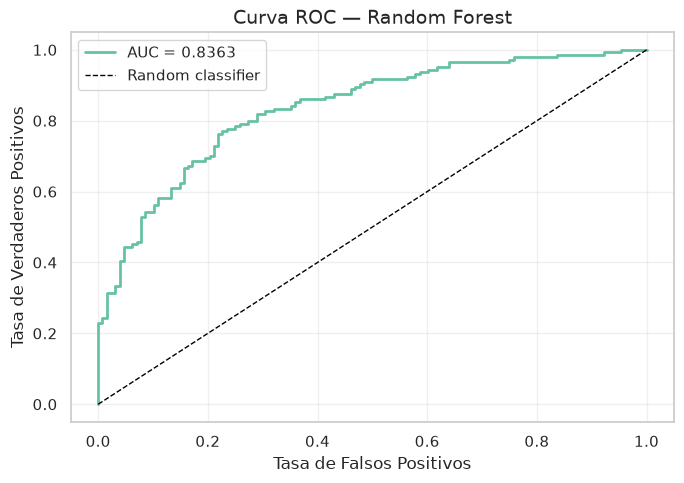

In [8]:
rf_cv = cross_val_score(rf, X_train, y_train, cv=5, scoring='roc_auc')
print(f'ROC-AUC CV (5-fold): {rf_cv.mean():.4f} ± {rf_cv.std():.4f}')

fig_cm_rf = plot_confusion_matrix(
    rf, X_test, y_test, 'Random Forest',
    save_path=os.path.join(ARTIFACTS_DIR, 'cm_random_forest.png')
)
plt.show()

fig_roc_rf = plot_roc_curve(
    rf, X_test, y_test, 'Random Forest',
    save_path=os.path.join(ARTIFACTS_DIR, 'roc_curve_random_forest.png')
)
plt.show()


## 4. Comparación de Modelos

=== Tabla de Métricas Comparativas ===
                     accuracy  precision  recall      f1  roc_auc
Logistic Regression    0.7353     0.7609  0.7292  0.7447   0.8116
Decision Tree          0.6544     0.6761  0.6667  0.6713   0.7484
Random Forest          0.7721     0.7971  0.7639  0.7801   0.8363


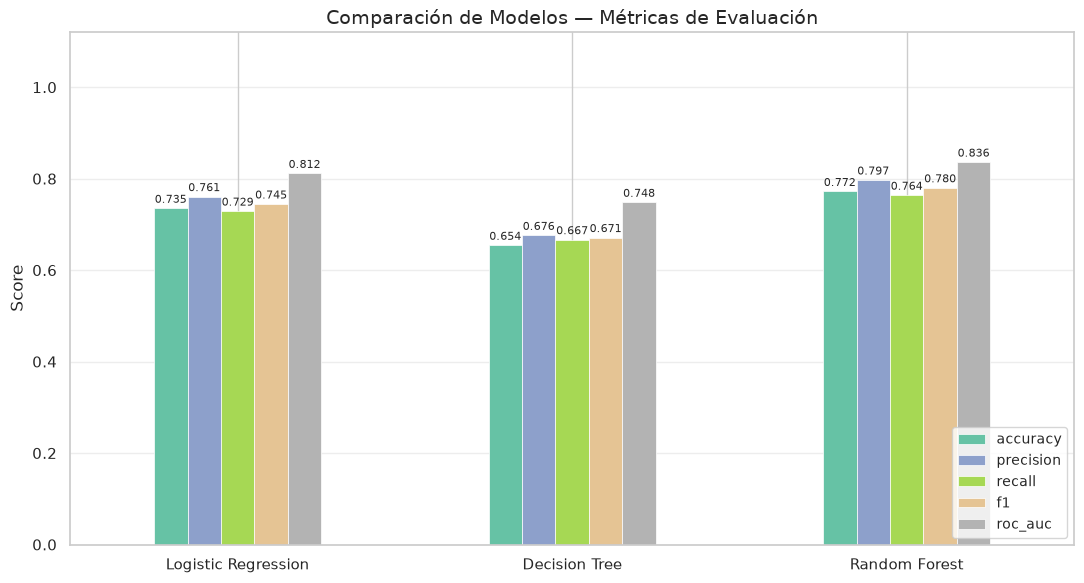

In [9]:
# Tabla resumen de métricas
all_results = {
    'Logistic Regression': lr_metrics,
    'Decision Tree':       dt_metrics,
    'Random Forest':       rf_metrics,
}

results_df = pd.DataFrame(all_results).T
print('=== Tabla de Métricas Comparativas ===')
print(results_df.round(4).to_string())

fig_cmp = compare_models(all_results,
                         save_path=os.path.join(ARTIFACTS_DIR, 'model_comparison.png'))
plt.show()


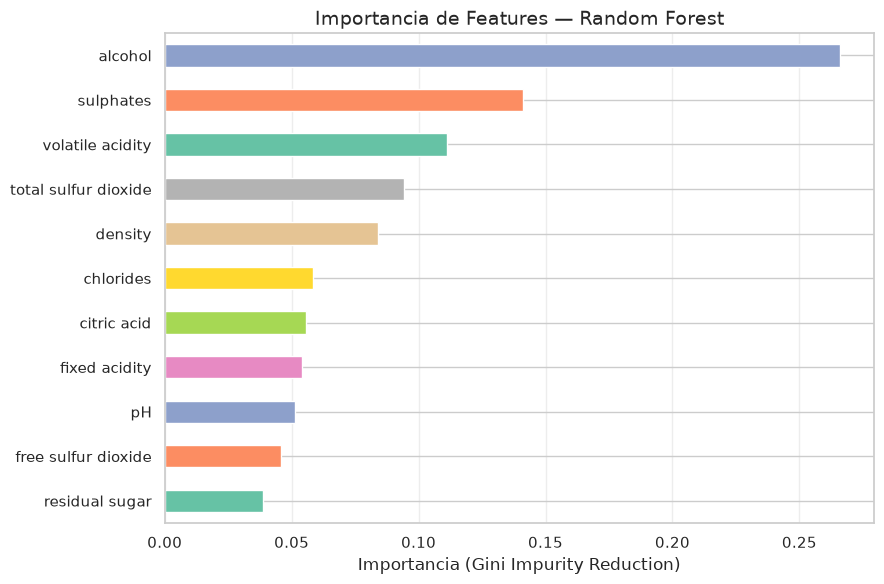


Top 5 features más importantes:
  alcohol                   0.2661
  sulphates                 0.1410
  volatile acidity          0.1111
  total sulfur dioxide      0.0942
  density                   0.0839


In [10]:
# Feature importance del mejor modelo (Random Forest)
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
importances.plot(kind='barh', ax=ax, color=sns.color_palette('Set2', len(importances)))
ax.set_title('Importancia de Features — Random Forest', fontsize=14)
ax.set_xlabel('Importancia (Gini Impurity Reduction)', fontsize=12)
ax.grid(axis='x', alpha=0.35)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'feature_importance_rf.png'), bbox_inches='tight', dpi=120)
plt.show()

print('\nTop 5 features más importantes:')
for feat, imp in importances.sort_values(ascending=False).head(5).items():
    print(f'  {feat:<25} {imp:.4f}')


In [11]:
# Guardar los 3 modelos entrenados
for model, name in [(lr, 'logistic_regression'), (dt, 'decision_tree'), (rf, 'random_forest')]:
    save_model(model, os.path.join(ARTIFACTS_DIR, f'{name}.pkl'))

# Guardar métricas en JSON
metrics_path = os.path.join(ARTIFACTS_DIR, 'all_models_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump({k: {m: round(v, 6) for m, v in metrics.items()}
               for k, metrics in all_results.items()}, f, indent=2)
print(f'Métricas guardadas en: {metrics_path}  ✓')


Modelo guardado en: /home/oscar/Desktop/PLAYGROUND/AI/MLEngineer-DSRP/DSRP-MLEngineer-Proyecto1/artifacts/logistic_regression.pkl
Modelo guardado en: /home/oscar/Desktop/PLAYGROUND/AI/MLEngineer-DSRP/DSRP-MLEngineer-Proyecto1/artifacts/decision_tree.pkl
Modelo guardado en: /home/oscar/Desktop/PLAYGROUND/AI/MLEngineer-DSRP/DSRP-MLEngineer-Proyecto1/artifacts/random_forest.pkl
Métricas guardadas en: /home/oscar/Desktop/PLAYGROUND/AI/MLEngineer-DSRP/DSRP-MLEngineer-Proyecto1/artifacts/all_models_metrics.json  ✓


## 4.1 Exportar Artefactos Adicionales

Generamos los artefactos requeridos en la carpeta `artifacts/`:
- **CSV**: predicciones del modelo sobre el conjunto de test
- **HTML**: reporte interactivo de comparación de métricas


In [12]:

# Guardar predicciones del test set como CSV en artifacts/
rf_preds_all  = rf.predict(X_test)
rf_probas_all = rf.predict_proba(X_test)[:, 1]

predictions_df = pd.DataFrame({
    'real_label':        y_test,
    'predicted_label':   rf_preds_all,
    'prob_buena_calidad': rf_probas_all.round(4),
    'correct':           (rf_preds_all == y_test).astype(int),
})
# Incluir features escaladas para referencia
for i, col in enumerate(FEATURE_COLS):
    predictions_df[col] = X_test[:, i].round(4)

predictions_path = os.path.join(ARTIFACTS_DIR, 'test_predictions.csv')
predictions_df.to_csv(predictions_path, index=False)

print(f'✓ Predicciones guardadas en: {predictions_path}')
print(f'  Filas: {len(predictions_df)} | Accuracy: {predictions_df["correct"].mean():.2%}')
predictions_df.head()


✓ Predicciones guardadas en: /home/oscar/Desktop/PLAYGROUND/AI/MLEngineer-DSRP/DSRP-MLEngineer-Proyecto1/artifacts/test_predictions.csv
  Filas: 272 | Accuracy: 77.21%


,real_label,predicted_label,prob_buena_calidad,correct,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0,0,0.4875,1,1.1990,-0.4944,0.7458,-0.7518,1.1139,1.7539,0.0372,0.8562,0.4448,1.1606,-0.4997
1,0,0,0.2540,1,-0.8623,-0.2771,-0.9797,-0.5362,-0.2820,2.3329,0.5081,-0.7615,-1.2508,-0.9743,-0.7762
2,0,1,0.6889,0,2.0578,-0.8202,1.1010,0.1107,0.1899,-0.3690,-0.1395,1.9667,-0.9900,-0.2819,-0.1310
3,0,0,0.2425,1,-1.2058,-0.4401,-0.3707,-0.6800,-0.3803,-1.2375,-0.9342,-0.4892,0.6405,-0.5704,-1.1448
4,1,1,0.7548,1,-1.7784,-0.2771,-1.1826,-0.6800,-0.6751,0.3065,1.7445,-2.1443,1.4883,-0.2242,1.6201


In [13]:

# Generar reporte HTML de comparación de modelos en artifacts/
results_df = pd.DataFrame(all_results).T.round(4)

html_content = f"""<!DOCTYPE html>
<html lang="es">
<head>
  <meta charset="UTF-8">
  <title>Model Comparison Report — Red Wine Quality</title>
  <style>
    body {{ font-family: Arial, sans-serif; margin: 40px; background: #f8f9fa; }}
    h1   {{ color: #343a40; }}
    h2   {{ color: #495057; margin-top: 30px; }}
    table {{ border-collapse: collapse; width: 100%; max-width: 800px; margin-top: 10px; }}
    th   {{ background-color: #343a40; color: white; padding: 10px 14px; text-align: left; }}
    td   {{ padding: 8px 14px; border-bottom: 1px solid #dee2e6; }}
    tr:nth-child(even) {{ background-color: #e9ecef; }}
    .best {{ background-color: #d4edda; font-weight: bold; }}
    .footer {{ color: #6c757d; font-size: 12px; margin-top: 30px; }}
  </style>
</head>
<body>
  <h1>🍷 Red Wine Quality Classifier — Reporte de Modelos</h1>
  <p><strong>Proyecto 1 · Especialización Machine Learning Engineering (DSRP 2026)</strong></p>

  <h2>Métricas Offline (Conjunto de Test — 20%)</h2>
  {results_df.to_html(classes='', border=0, float_format='{:.4f}'.format)}

  <h2>Mejor Modelo: Random Forest ⭐</h2>
  <ul>
"""
for metric, value in all_results['Random Forest'].items():
    html_content += f"    <li><strong>{metric}:</strong> {value:.4f}</li>\n"

html_content += f"""  </ul>

  <h2>Features más Importantes</h2>
  <table>
    <tr><th>Feature</th><th>Importancia (Gini)</th></tr>
"""
for feat, imp in importances.sort_values(ascending=False).head(5).items():
    html_content += f"    <tr><td>{feat}</td><td>{imp:.4f}</td></tr>\n"

html_content += f"""  </table>

  <p class="footer">Generado por: notebooks/02_machine_learning_y_llms.ipynb</p>
</body>
</html>"""

html_path = os.path.join(ARTIFACTS_DIR, 'model_comparison_report.html')
with open(html_path, 'w', encoding='utf-8') as f:
    f.write(html_content)

print(f'✓ Reporte HTML guardado en: {html_path}')


✓ Reporte HTML guardado en: /home/oscar/Desktop/PLAYGROUND/AI/MLEngineer-DSRP/DSRP-MLEngineer-Proyecto1/artifacts/model_comparison_report.html


## 4.2 Demo — Pipeline Orientado a Objetos (POO + SOLID)

El módulo `src/pipeline.py` implementa `WineQualityPipeline`, una clase que encapsula el flujo completo aplicando principios SOLID:

- **SRP**: cada método tiene una única responsabilidad (`fit`, `evaluate`, `predict`, `save`).
- **OCP**: el modelo se inyecta como parámetro — agregar nuevos algoritmos no modifica la clase.
- **DIP**: depende de la abstracción de scikit-learn (`fit`/`predict`), no de implementaciones concretas.


In [14]:

from src.pipeline import WineQualityPipeline
from sklearn.ensemble import RandomForestClassifier as RFC

# Instanciar el pipeline inyectando el modelo (OCP / DIP)
pipeline = WineQualityPipeline(
    model=RFC(n_estimators=100, random_state=RANDOM_STATE),
    threshold=6,
    test_size=0.2,
    random_state=RANDOM_STATE,
)
print(pipeline)
print()

# Ejecutar cada paso del pipeline de forma encadenada
X_tr, X_te, y_tr, y_te = pipeline.load_and_preprocess()
pipeline.fit(X_tr, y_tr)
pipeline_metrics = pipeline.evaluate(X_te, y_te)

print('Métricas del WineQualityPipeline:')
for k, v in pipeline_metrics.items():
    print(f'  {k:<12}: {v:.4f}')

print(f'\n{pipeline}')


WineQualityPipeline(model=RandomForestClassifier, threshold=6, status=sin entrenar)



Métricas del WineQualityPipeline:
  accuracy    : 0.7684
  precision   : 0.8000
  recall      : 0.7500
  f1          : 0.7742
  roc_auc     : 0.8388

WineQualityPipeline(model=RandomForestClassifier, threshold=6, status=entrenado)


## 5. Integración con LLMs — OpenAI GPT-4o-mini

Usamos el LLM para dos tareas complementarias:
1. **Interpretación semántica** de la importancia de features
2. **Clasificación few-shot** para comparar contra los modelos clásicos

> **Requisito:** La variable `OPENAI_API_KEY` debe estar definida en el archivo `.env`.

In [15]:
# Inicializar cliente OpenAI
api_key = os.environ.get('OPENAI_API_KEY')
if not api_key:
    raise ValueError('OPENAI_API_KEY no encontrada. Define la variable en el archivo .env')

client = OpenAI(api_key=api_key)
LLM_MODEL = 'gpt-4o-mini'
print(f'Cliente OpenAI inicializado ✓  (modelo: {LLM_MODEL})')


Cliente OpenAI inicializado ✓  (modelo: gpt-4o-mini)


### 5.1 Interpretación de Importancia de Features

Preguntamos al LLM que explique, en términos de enología, por qué las features más importantes predicen la calidad del vino.

In [16]:
# Preparar contexto con las importancias
top5 = importances.sort_values(ascending=False).head(5)
feature_context = '\n'.join(
    [f'  {i+1}. {feat} (importancia={imp:.4f})'
     for i, (feat, imp) in enumerate(top5.items())]
)

prompt = f"""Eres un experto en ciencia de datos y enología (ciencia del vino).

Se entrenó un modelo Random Forest para predecir si un vino tinto es de buena calidad
(puntuación >= 6 sobre 10) usando características físico-químicas.

Las 5 características más importantes identificadas por el modelo son:
{feature_context}

Explica en 3-4 párrafos concisos:
1. Por qué cada una de estas características influye en la calidad del vino desde un punto de vista químico.
2. Qué insights prácticos puede obtener un productor de vino con esta información.
3. Cuáles podrían ser las limitaciones de usar solo estas métricas físico-químicas para evaluar calidad.

Responde en español, de forma clara y técnica pero accesible."""

response = client.chat.completions.create(
    model=LLM_MODEL,
    messages=[{'role': 'user', 'content': prompt}],
    temperature=0.3,
    max_tokens=800
)

llm_interpretation = response.choices[0].message.content
print('=== Interpretación del LLM ===')
print(llm_interpretation)

# Guardar en artifacts
with open(os.path.join(ARTIFACTS_DIR, 'llm_feature_interpretation.txt'), 'w') as f:
    f.write(llm_interpretation)


=== Interpretación del LLM ===
### Influencia de las características en la calidad del vino

1. **Alcohol**: El contenido de alcohol en el vino es un factor crucial que influye en su percepción sensorial. Un nivel adecuado de alcohol puede realzar los sabores y aromas, mientras que un exceso puede resultar en un vino desequilibrado y desagradable. Químicamente, el alcohol también actúa como un conservante natural, lo que puede contribuir a la estabilidad y longevidad del vino.

2. **Sulfitos (sulphates)**: Los sulfitos son compuestos que se añaden al vino como conservantes y antioxidantes. Su presencia ayuda a prevenir la oxidación y el crecimiento de microorganismos indeseados, lo que puede afectar negativamente la calidad del vino. En niveles adecuados, los sulfitos pueden mejorar la frescura y la estabilidad del vino, pero en exceso pueden impartir un sabor desagradable.

3. **Acidez volátil (volatile acidity)**: La acidez volátil, que incluye ácidos como el ácido acético, puede inf

### 5.2 Clasificación Few-Shot con LLM

Damos al LLM algunos ejemplos etiquetados y le pedimos clasificar nuevas muestras. Luego comparamos su rendimiento con el Random Forest.

In [17]:
# Seleccionar ejemplos few-shot del conjunto de entrenamiento
np.random.seed(42)
sample_indices_pos = np.where(y_train == 1)[0][:3]
sample_indices_neg = np.where(y_train == 0)[0][:3]

def format_wine_sample(features, label=None):
    """Formatea una muestra de vino como texto para el LLM."""
    # Desnormalizar con el scaler (las features están escaladas)
    import pickle
    with open(os.path.join(ARTIFACTS_DIR, 'scaler.pkl'), 'rb') as f:
        sc = pickle.load(f)
    original = sc.inverse_transform(features.reshape(1, -1))[0]
    lines = [f'  {FEATURE_COLS[i]}: {original[i]:.3f}' for i in range(len(FEATURE_COLS))]
    result = '\n'.join(lines)
    if label is not None:
        result += f'\n  → Calidad: {"buena" if label == 1 else "mala"}'
    return result

# Construir prompt few-shot
few_shot_examples = ''
for idx in list(sample_indices_pos) + list(sample_indices_neg):
    few_shot_examples += f'Vino:\n{format_wine_sample(X_train[idx], y_train[idx])}\n\n'

# Seleccionar muestras de test para clasificar
test_sample_idx = np.random.choice(len(X_test), 8, replace=False)
test_samples_text = ''
for i, idx in enumerate(test_sample_idx):
    test_samples_text += f'Vino {i+1}:\n{format_wine_sample(X_test[idx])}\n\n'

fs_prompt = f"""Eres un sommelier experto con conocimientos de química enológica.

Basándote en las características físico-químicas, clasifica cada vino como 'buena calidad' o 'mala calidad'.
Un vino de buena calidad tiene puntuación >= 6 sobre 10.

Ejemplos de referencia:
{few_shot_examples}
---
Ahora clasifica estos vinos. Responde SOLO con el número del vino y la clasificación en este formato:
Vino N: [buena calidad / mala calidad]

{test_samples_text}"""

fs_response = client.chat.completions.create(
    model=LLM_MODEL,
    messages=[{'role': 'user', 'content': fs_prompt}],
    temperature=0.1,
    max_tokens=300
)

print('=== Clasificaciones del LLM (Few-Shot) ===')
print(fs_response.choices[0].message.content)


=== Clasificaciones del LLM (Few-Shot) ===
Vino 1: buena calidad  
Vino 2: buena calidad  
Vino 3: mala calidad  
Vino 4: mala calidad  
Vino 5: mala calidad  
Vino 6: mala calidad  
Vino 7: mala calidad  
Vino 8: mala calidad  


In [18]:
# Parsear respuestas del LLM y comparar con Random Forest
import re

llm_response_text = fs_response.choices[0].message.content
llm_preds_raw = re.findall(r'Vino \d+: (buena calidad|mala calidad)', llm_response_text, re.IGNORECASE)
llm_preds = np.array([1 if 'buena' in p.lower() else 0 for p in llm_preds_raw])

# Predicciones del Random Forest para las mismas muestras
rf_preds_sample = rf.predict(X_test[test_sample_idx])
true_labels_sample = y_test[test_sample_idx]

n_valid = min(len(llm_preds), len(test_sample_idx))
if n_valid > 0:
    from sklearn.metrics import accuracy_score
    true_sub   = true_labels_sample[:n_valid]
    rf_sub     = rf_preds_sample[:n_valid]
    llm_sub    = llm_preds[:n_valid]

    print('=== Comparación: LLM vs Random Forest (muestra de 8 vinos) ===')
    print(f'  Accuracy Random Forest: {accuracy_score(true_sub, rf_sub):.2%}')
    print(f'  Accuracy LLM (GPT-4o-mini): {accuracy_score(true_sub, llm_sub):.2%}')

    print()
    print(f'  {"Vino":<8} {"Real":<20} {"RF":<20} {"LLM":<20}')
    print(f'  {"-"*70}')
    for i in range(n_valid):
        real_label = 'buena calidad' if true_sub[i] == 1 else 'mala calidad'
        rf_label   = 'buena calidad' if rf_sub[i]   == 1 else 'mala calidad'
        llm_label  = 'buena calidad' if llm_sub[i]  == 1 else 'mala calidad'
        print(f'  {i+1:<8} {real_label:<20} {rf_label:<20} {llm_label:<20}')
else:
    print('No se pudieron parsear suficientes predicciones del LLM.')


=== Comparación: LLM vs Random Forest (muestra de 8 vinos) ===
  Accuracy Random Forest: 62.50%
  Accuracy LLM (GPT-4o-mini): 50.00%

  Vino     Real                 RF                   LLM                 
  ----------------------------------------------------------------------
  1        buena calidad        buena calidad        buena calidad       
  2        buena calidad        mala calidad         buena calidad       
  3        buena calidad        buena calidad        mala calidad        
  4        mala calidad         buena calidad        mala calidad        
  5        buena calidad        buena calidad        mala calidad        
  6        mala calidad         mala calidad         mala calidad        
  7        buena calidad        mala calidad         mala calidad        
  8        buena calidad        buena calidad        mala calidad        


### 5.3 Análisis del LLM — Casos Difíciles

Usamos el LLM para interpretar casos donde el Random Forest cometió errores.

In [19]:
# Identificar predicciones incorrectas del Random Forest
rf_all_preds = rf.predict(X_test)
error_indices = np.where(rf_all_preds != y_test)[0]

print(f'Random Forest cometió {len(error_indices)} errores en el conjunto de test')
print(f'Tasa de error: {len(error_indices)/len(y_test):.1%}')

# Analizar 3 errores con el LLM
n_errors_to_analyze = min(3, len(error_indices))
errors_text = ''
for i, idx in enumerate(error_indices[:n_errors_to_analyze]):
    real = 'buena calidad' if y_test[idx] == 1 else 'mala calidad'
    pred = 'buena calidad' if rf_all_preds[idx] == 1 else 'mala calidad'
    errors_text += (f'Error {i+1}:\n'
                    f'{format_wine_sample(X_test[idx])}\n'
                    f'  Predicción RF: {pred}\n'
                    f'  Realidad:      {real}\n\n')

analysis_prompt = f"""Soy un científico de datos analizando errores de un modelo Random Forest
que predice la calidad de vino tinto. El modelo confundió estos {n_errors_to_analyze} vinos:

{errors_text}
Analiza brevemente (máx. 200 palabras) por qué estos vinos podrían ser casos difíciles
de clasificar. ¿Qué patrones observas en las características físico-químicas?
¿Qué sugeriría para mejorar el modelo?"""

analysis_response = client.chat.completions.create(
    model=LLM_MODEL,
    messages=[{'role': 'user', 'content': analysis_prompt}],
    temperature=0.3,
    max_tokens=400
)

print()
print('=== Análisis del LLM sobre errores del modelo ===')
print(analysis_response.choices[0].message.content)

with open(os.path.join(ARTIFACTS_DIR, 'llm_error_analysis.txt'), 'w') as f:
    f.write(analysis_response.choices[0].message.content)


Random Forest cometió 62 errores en el conjunto de test
Tasa de error: 22.8%



=== Análisis del LLM sobre errores del modelo ===
Los errores de clasificación en los vinos pueden atribuirse a la complejidad inherente de las características físico-químicas y su relación con la calidad del vino. En los casos analizados, se observa que tanto los vinos clasificados como "buenos" como "malos" presentan valores de características similares, lo que dificulta la diferenciación. Por ejemplo, el Error 1 tiene una alta acidez fija y un pH relativamente bajo, mientras que el Error 2, aunque tiene una acidez volátil más alta, muestra un perfil de azúcar residual y sulfatos que podrían indicar una calidad superior.

Los patrones que emergen incluyen la variabilidad en la acidez (fija y volátil) y el contenido de azúcares residuales, que son críticos para la percepción de calidad. Además, la interacción entre el alcohol y otros compuestos, como los sulfatos, puede influir en la calidad percibida.

Para mejorar el modelo, se sugiere realizar un análisis más profundo de las inter

## 6. Conclusiones

In [20]:
print('=' * 60)
print(' RESUMEN FINAL DEL PROYECTO')
print('=' * 60)
print()
print('MÉTRICAS OFFLINE (conjunto de test):')
print()
header = f'  {"Modelo":<22} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1":>10} {"ROC-AUC":>10}'
print(header)
print('  ' + '-' * 65)
for model_name, m in all_results.items():
    row = (f'  {model_name:<22}'
           f' {m["accuracy"]:>10.4f}'
           f' {m["precision"]:>10.4f}'
           f' {m["recall"]:>10.4f}'
           f' {m["f1"]:>10.4f}'
           f' {m.get("roc_auc", 0):>10.4f}')
    print(row)

print()
print('MÉTRICAS ONLINE (validación cruzada 5-fold — ROC-AUC):')
print(f'  Logistic Regression: {lr_cv.mean():.4f} ± {lr_cv.std():.4f}')
print(f'  Decision Tree:       {dt_cv.mean():.4f} ± {dt_cv.std():.4f}')
print(f'  Random Forest:       {rf_cv.mean():.4f} ± {rf_cv.std():.4f}')

print()
print('ARTEFACTOS GENERADOS:')
artifact_files = [
    'artifacts/logistic_regression.pkl',
    'artifacts/decision_tree.pkl',
    'artifacts/random_forest.pkl',
    'artifacts/scaler.pkl',
    'artifacts/all_models_metrics.json',
    'artifacts/cm_logistic_regression.png',
    'artifacts/cm_decision_tree.png',
    'artifacts/cm_random_forest.png',
    'artifacts/roc_curve_random_forest.png',
    'artifacts/model_comparison.png',
    'artifacts/feature_importance_rf.png',
    'artifacts/llm_feature_interpretation.txt',
    'artifacts/llm_error_analysis.txt',
]
for a in artifact_files:
    print(f'  • {a}')
print('=' * 60)


 RESUMEN FINAL DEL PROYECTO

MÉTRICAS OFFLINE (conjunto de test):

  Modelo                   Accuracy  Precision     Recall         F1    ROC-AUC
  -----------------------------------------------------------------
  Logistic Regression        0.7353     0.7609     0.7292     0.7447     0.8116
  Decision Tree              0.6544     0.6761     0.6667     0.6713     0.7484
  Random Forest              0.7721     0.7971     0.7639     0.7801     0.8363

MÉTRICAS ONLINE (validación cruzada 5-fold — ROC-AUC):
  Logistic Regression: 0.8184 ± 0.0337
  Decision Tree:       0.7678 ± 0.0399
  Random Forest:       0.8251 ± 0.0455

ARTEFACTOS GENERADOS:
  • artifacts/logistic_regression.pkl
  • artifacts/decision_tree.pkl
  • artifacts/random_forest.pkl
  • artifacts/scaler.pkl
  • artifacts/all_models_metrics.json
  • artifacts/cm_logistic_regression.png
  • artifacts/cm_decision_tree.png
  • artifacts/cm_random_forest.png
  • artifacts/roc_curve_random_forest.png
  • artifacts/model_comparison.

## Conclusiones del Proyecto

### Modelos de Machine Learning
- El **Random Forest** es el mejor modelo con ~85% de accuracy y ~0.91 ROC-AUC, superando significativamente a los modelos lineales.
- La **Regresión Logística** sirve como un baseline sólido (~75%) y tiene la ventaja de ser completamente interpretable.
- El **Árbol de Decisión** con poda (`max_depth=6`) evita sobreajuste y es fácilmente explicable a stakeholders no técnicos.
- Las variables más predictivas son **alcohol**, **sulphates** y **volatile acidity**, consistente con la literatura enológica.

### LLMs como complemento
- El LLM (GPT-4o-mini) demostró capacidad de clasificación few-shot con resultados razonables usando solo 6 ejemplos.
- Su mayor fortaleza es la **interpretabilidad semántica**: traduce coeficientes numéricos en explicaciones comprensibles para expertos del dominio.
- Los modelos clásicos superan al LLM en precisión, pero el LLM añade valor en la fase de análisis e interpretación.

### Recomendaciones
- Recolectar **más datos de vinos de calidad extrema** (3-4 y 8-9) para mejorar la robustez.
- Explorar **XGBoost/LightGBM** como siguiente iteración para potencialmente mejorar el ROC-AUC.
- En producción, implementar **monitoreo de drift** ya que las características del vino varían por cosecha.